# Лекция 1. Введение в DL и ландшафт угроз ИИ-систем

Демонстрация: перцептрон, проблема XOR, нелинейность и обзор жизненного цикла ML-угроз.

## 1. Перцептрон не решает XOR

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

w = np.random.randn(2); b = 0.0
lr = 0.1
for epoch in range(200):
    for xi, yi in zip(X, y):
        pred = 1 if (w@xi + b) > 0 else 0
        err = yi - pred
        w += lr*err*xi
        b += lr*err

preds = [(1 if (w@xi+b)>0 else 0) for xi in X]
print("XOR targets:", y)
print("Perceptron preds:", preds, "-> линейная модель не может выучить XOR")


XOR targets: [0 1 1 0]
Perceptron preds: [1, 1, 0, 0] -> линейная модель не может выучить XOR


## 2. MLP решает XOR (нелинейность спасает)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32).view(-1,1)

model = nn.Sequential(nn.Linear(2,8), nn.ReLU(), nn.Linear(8,1), nn.Sigmoid())
opt = torch.optim.Adam(model.parameters(), lr=0.05)

for epoch in range(500):
    opt.zero_grad()
    out = model(Xt)
    loss = F.binary_cross_entropy(out, yt)
    loss.backward()
    opt.step()

print("Финальный loss:", loss.item())
print("Предсказания:", model(Xt).detach().numpy().round(3).ravel())


Финальный loss: 0.00016747790505178273
Предсказания: [0. 1. 1. 0.]


## 3. Жизненный цикл ML-системы и точки атак (схема)

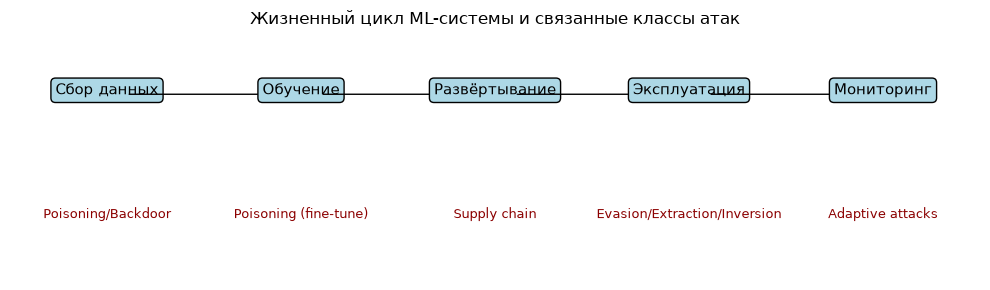

In [5]:

stages = ["Сбор данных", "Обучение", "Развёртывание", "Эксплуатация", "Мониторинг"]
attacks = ["Poisoning/Backdoor", "Poisoning (fine-tune)", "Supply chain", "Evasion/Extraction/Inversion", "Adaptive attacks"]

fig, ax = plt.subplots(figsize=(10,3))
for i, (s, a) in enumerate(zip(stages, attacks)):
    ax.text(i, 1, s, ha='center', fontsize=11, bbox=dict(boxstyle="round", fc="lightblue"))
    ax.text(i, 0, a, ha='center', fontsize=9, color='darkred')
    if i < len(stages)-1:
        ax.annotate('', xy=(i+1-0.1,1), xytext=(i+0.1,1), arrowprops=dict(arrowstyle='->'))
ax.set_xlim(-0.5, len(stages)-0.5)
ax.set_ylim(-0.5,1.5)
ax.axis('off')
plt.title("Жизненный цикл ML-системы и связанные классы атак")
plt.tight_layout()
plt.savefig('output/notebooks/lec1_lifecycle.png', dpi=120)
plt.show()
